# Wind Farm Power Gen Optimization

Looking at wake generation and its impact on total wind farm power generation.

### Imports

In [19]:
# Imports

import grama as gr
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from grama.marginals import MarginalNamed
DF = gr.Intention()
%matplotlib inline

from grama.models import make_prlc_rand

### Wind Farm Function

In [3]:
# Farm Model with all equations
def windfarm_model(u1, theta, kw, x1, x2, x3, x4, x5, x6, y1, y2, y3, y4, y5, y6): #*args
    """
    Inputs (matching grama var_names list):
        u1 (float): Free-stream wind speed (m/s)
        theta (float): Wind direction (rads, 0 = wind from +x-dir)
        kw (float): Wake decay coefficient (non)
        x1...x6 (float): Turbine x-positions (m)
        y1...y6 (float): Turbine y-positions (m)
        # args = [
        #     x1, ..., x6
        #     y1, ..., y6
        # ]

    Output:
        P_total (float): Total power produced by wind farm in current configuration.
        g1_2...g5_6 (float): Pairwise Euclidian distance between turbines (15 vals)
    """
    # Parameters 
    Ct = 0.75
    Cp = 0.4
    rr = 15.05
    rho = 1.225
    N = 6
    A_rotor = np.pi * rr**2

    # Position vectors
    xs = np.array([x1, x2, x3, x4, x5, x6], dtype=float)
    ys = np.array([y1, y2, y3, y4, y5, y6], dtype=float)

    # Wind unit vector - eq 1
    e_w = np.array([np.cos(theta), np.sin(theta)]) # eq 1

    # Wake deficits for indiviual turbines
    u_eff = np.zeros(N)

    for turb in range(N):
        r_n = np.array([xs[turb], ys[turb]])
        delta_sq_sum = 0.0

        for i in range(N):
            if i == turb:
                continue
            
            r_i = np.array([xs[i], ys[i]]) # eq 2
            r_ij = r_n - r_i # eq 3

            # Downwind distance (positive value means turbine n is downstream of turbine i)
            x_ij_w = np.dot(r_ij, e_w) # eq 4
            if x_ij_w <= 0: # if i is not upstream of n
                continue

            # crosswind distance
            y_ij_w = np.linalg.norm(r_ij - x_ij_w * e_w) # eq 5

            # wake radius at n's downstream distance
            r_w = rr + kw + x_ij_w # eq 6

            # distance between wake center and rotor center
            d = y_ij_w

            # calculating overlap area - eq 8
            if d >= r_w + rr:
                continue # no overlap - no deficit contribution
            elif d + rr <= r_w:
                A_overlap = A_rotor # rotor is fully inside of the wake
            elif d + r_w <= rr:
                A_overlap = np.pi * r_w**2 # wake fully inside rotor
            else: # partial overlap
                term1 = r_w**2 * np.arccos(
                    np.clip((d**2 + r_w**2 - rr**2) / (2 * d * r_w), -1, 1)
                )
                term2 = rr**2 * np.arccos(
                    np.clip((d**2 + rr**2 - r_w**2) / (2 * d * rr), -1, 1)
                )
                term3 = 0.5 * np.sqrt(
                    max(0.0,
                        (-d + r_w + rr) * (d + r_w - rr) *
                        (d - r_w + rr) * (d + r_w + rr)
                    )
                )
                A_overlap = term1 + term2 - term3 # eq 8
            
            # raw deficit from turbine i on turbine n
            delta_ij = (1 - np.sqrt(1 - Ct)) / (1 + kw + x_ij_w / rr)**2 # eq 7

            # Effective deficit (scaled by overlap)
            delta_ij_eff = delta_ij * (A_overlap / A_rotor) # eq 9
            delta_sq_sum += delta_ij_eff**2

        # combined deficit and wind speed
        delta_n = np.sqrt(delta_sq_sum) # eq 10
        u_eff[turb] = u1 * max(0.0, 1.0 - delta_n) # eq 11

    # Power generated by each turbine
    P = 0.5 * rho * A_rotor * Cp * u_eff**3 # eq 12

    # Total Power generated by farm
    P_total = float(np.sum(P)) # eq 13
    neg_P_total = -1 * P_total # need to minimize for this
    
    # pairwise distances (for constraints)
    pairwise_distance = []
    for i in range(N):
        for j in range(i+1, N):
            dist = float(np.sqrt((xs[i] - xs[j])**2 + (ys[i] - ys[j])**2)) # eq 14
            pairwise_distance.append(dist)
    
    # return
    return(neg_P_total, *pairwise_distance)

### Uncertain Variables

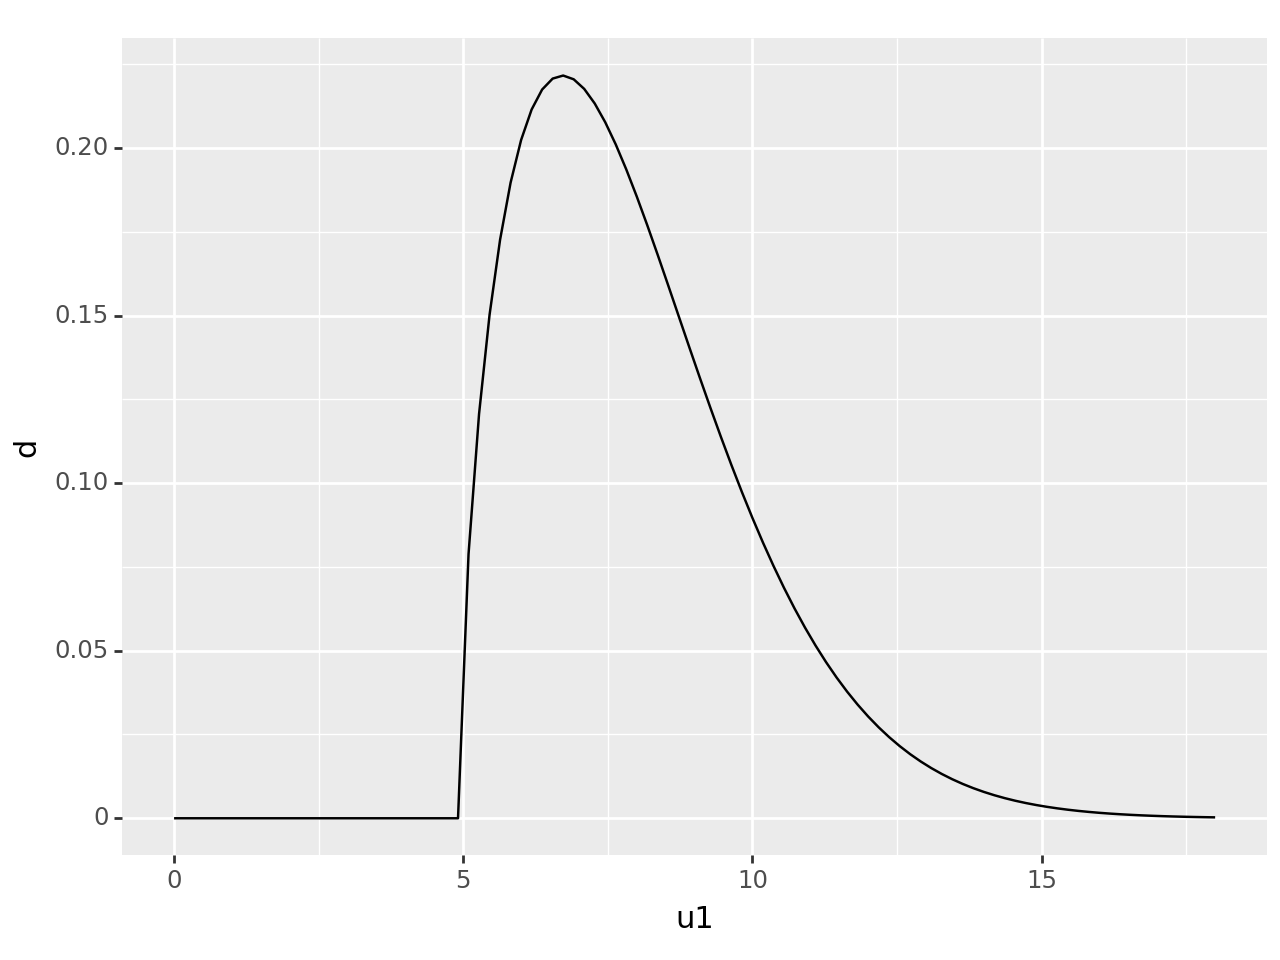

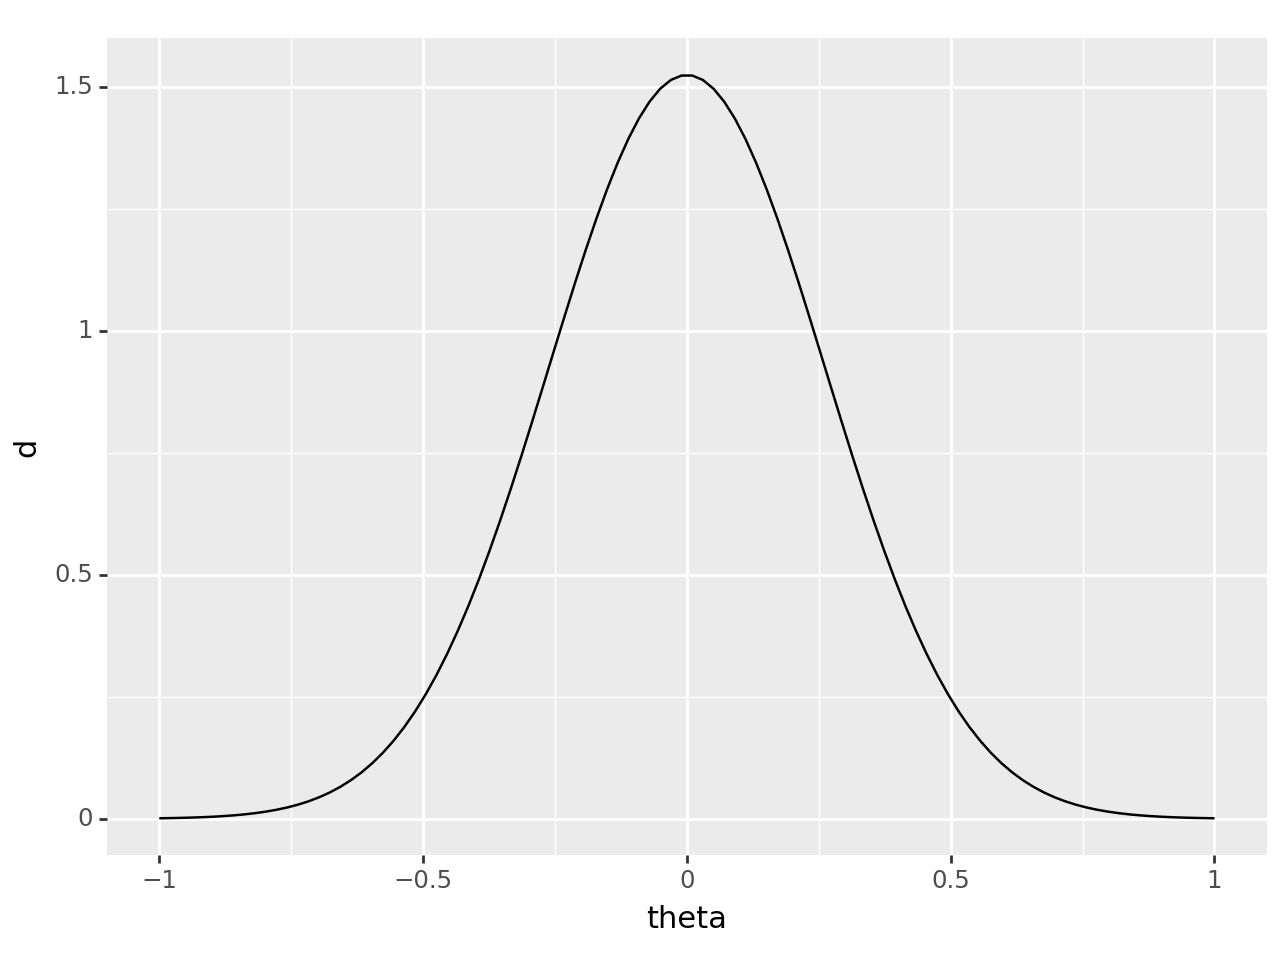

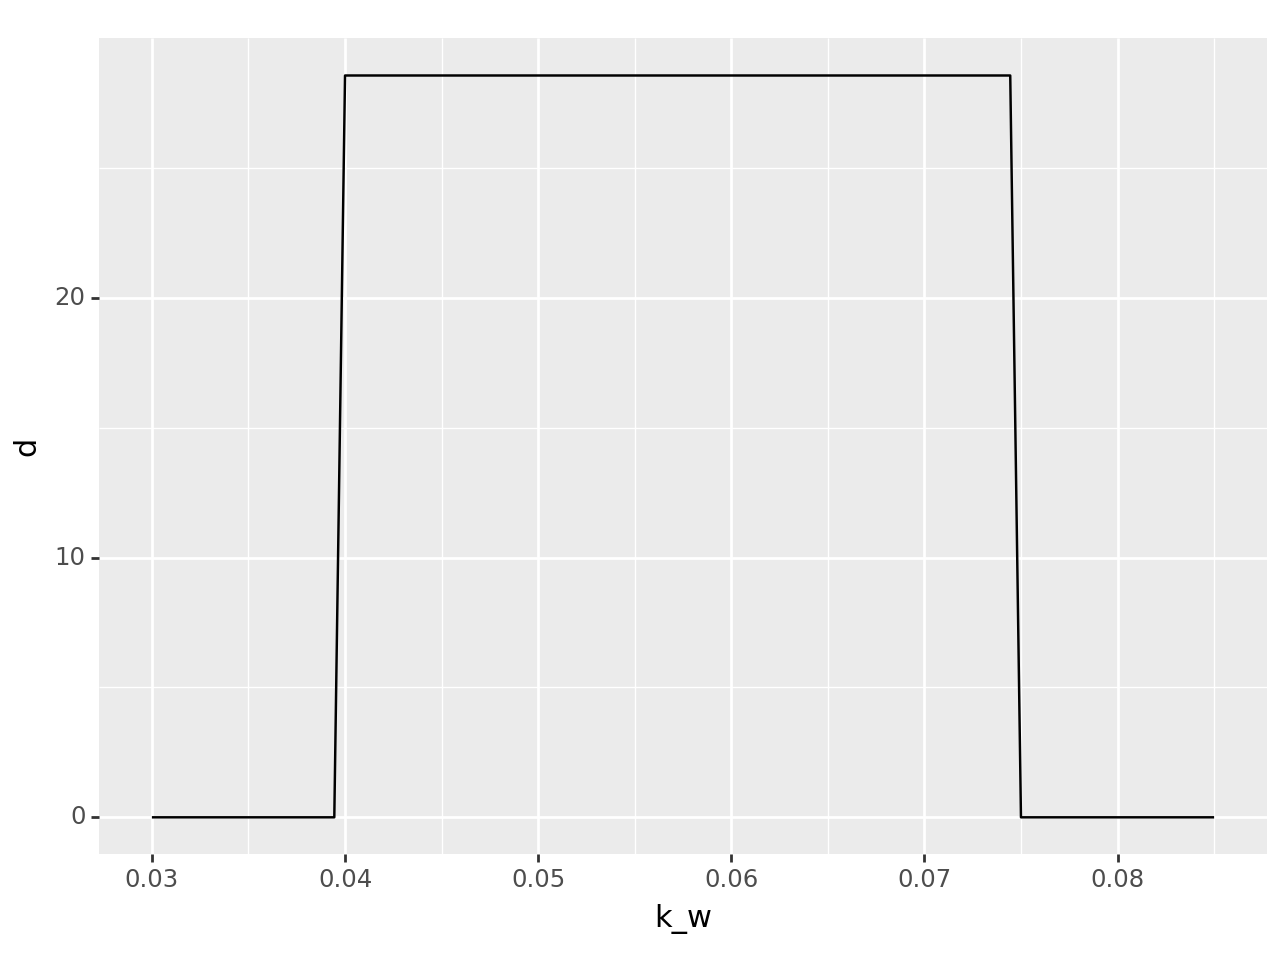

In [20]:
marg_u1 = gr.marg_mom("weibull_min", mean=8, sd=2, skew=1)
marg_theta = gr.marg_mom("norm", mean=0, sd = np.deg2rad(15))
# this one needed a different line to not center on 0
marg_kw = MarginalNamed(d_name="uniform", d_param={"loc": 0.04, "scale": 0.035})

plot1 = (
    gr.df_make(u1=gr.linspace(0, 18, 100))
    >> gr.tf_mutate(d=marg_u1.d(DF.u1))

    >> gr.ggplot(gr.aes("u1", "d"))
    + gr.geom_line()
)

plot2 = (
    gr.df_make(theta=gr.linspace(-1.0, 1.0, 100)) #0.523 rads = 30 degrees
    >> gr.tf_mutate(d=marg_theta.d(DF.theta))

    >> gr.ggplot(gr.aes("theta", "d"))
    + gr.geom_line()
)

plot3 = (
    gr.df_make(k_w=gr.linspace(0.03, 0.085, 100))
    >> gr.tf_mutate(d=marg_kw.d(DF.k_w))
    >> gr.ggplot(gr.aes("k_w", "d"))
    + gr.geom_line()
)


print(plot1)
print(plot2)
print(plot3)

In [19]:
# Define random variable marginals - need to visualize these
marginals = gr.cp_marginals(
    u1=marg_u1, # centered around 7-9m/s
    theta=marg_theta, # 95% within +- 30degrees
    kw=dict(dist="uniform", loc=0.04, scale=0.035)
)

# Defining correlation copula - for now u and theta are independent
# df_corr = pd.DataFrame({
#     "u1":     [1.0,  0.0, 0.0],
#     "theta": [0.0,  1.0, 0.0],
#     "kw":    [0.0,  0.0, 1.0]
# }, index=["u1", "theta", "kw"])
df_corr = gr.df_make(
    var1=[   "u1", "u1", "theta"],
    var2=["theta", "kw",    "kw"],
    corr=[    0.0,   0.0,   0.0],
)

copula = gr.cp_copula_gaussian(df_corr=df_corr)

### Model Setup

In [20]:
# Build list of variable names (copy and paster into 'var' field in model def)
N = 6
var_names = (
    ["u1", "theta", "kw"] +
    [f"x{i+1}" for i in range(N)] +
    [f"y{i+1}" for i in range(N)]
)
print(var_names)

# Defining design variable available values (bounds)
bounds = {}
for i in range(N):
    bounds[f"x{i+1}"] = (0, 1000)
    bounds[f"y{i+1}"] = (0, 500)

# building list of output names
out_names = ["neg_P_total"] + [f"g{i}_{j}" for i in range(1, N+1) for j in range(i+1, N+1)]


# Building the Model!!!
md_windfarm = (
    gr.Model("Wind Farm")
    >> gr.cp_function(
        fun = windfarm_model,
        var=var_names, 
        out=out_names # return the pairwise distances between each turbine
    )
    >> marginals # references marginals definitions above
    >> copula # references copula definition above
    >> gr.cp_bounds(**bounds) # constrains options for design variables
)

# will need to pass the pairwise distance output to gr.ev_min as constraints -> also optimize for -P_total

md_windfarm 

['u1', 'theta', 'kw', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6']


/home/amineeva/anaconda3/envs/pdo/lib/python3.9/site-packages/grama/marginals.py:338: RuntimeWarning: divide by zero encountered in scalar divide


model: Wind Farm

  inputs:
    var_det:
      y2: [0, 500]
      x1: [0, 1000]
      y5: [0, 500]
      x2: [0, 1000]
      y1: [0, 500]
      x3: [0, 1000]
      x4: [0, 1000]
      x6: [0, 1000]
      x5: [0, 1000]
      y6: [0, 500]
      y3: [0, 500]
      y4: [0, 500]

    var_rand:
      u1: (+0) weibull_min, {'mean': '8.000e+00', 's.d.': '2.000e+00', 'COV': 0.25, 'skew.': 1.0, 'kurt.': 4.16}
      theta: (+0) norm, {'mean': '0.000e+00', 's.d.': '2.600e-01', 'COV': inf, 'skew.': 0.0, 'kurt.': 3.0}
      kw: (+0) uniform, {'mean': '6.000e-02', 's.d.': '1.000e-02', 'COV': 0.18, 'skew.': 0.0, 'kurt.': 1.8}

    copula:
      Gaussian copula with correlations:
    var1   var2  corr
0     u1  theta   0.0
1     u1     kw   0.0
2  theta     kw   0.0

  functions:
      f0: ['u1', 'theta', 'kw', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6'] -> ['neg_P_total', 'g1_2', 'g1_3', 'g1_4', 'g1_5', 'g1_6', 'g2_3', 'g2_4', 'g2_5', 'g2_6', 'g3_4', 'g3_5', 'g3_6', 'g4_5',

### Optimization

In [ ]:
# Evaluate expected power

min_spacing = 2.5 * 2 * 15.05 # 75.25m
xy_vars = (
    [f"x{i+1}" for i in range(N)] +
    [f"y{i+1}" for i in range(N)]
)
spacing_constraints = [
    f"g{i}_{j} - {min_spacing}"
    for i in range(1, N+1)
    for j in range(i+1, N+1)
]

# want to maximise expected power across uncertain inputs, so for candidate layouts run MC - WIP...
df_opt_res = (
    md_windfarm
    >> gr.ev_min(
        out_min="neg_P_total",
        out_leq=spacing_constraints
    )
)

df_opt_res_final = (
    md_windfarm
    >> gr.ev_sample(n=500, df_det=df_opt_res)   # Monte Carlo
    >> gr.tf_summarize(E_P=gr.mean("neg_P_total"))
)

print(df_opt_res_final)

ValueError: model must have no random variables

## For later

eval_sample() is rounding n...
Estimated runtime: 0.0000 sec
eval_sample() is rounding n...
Estimated runtime: 0.0000 sec
eval_sample() is rounding n...
Estimated runtime: 0.0000 sec
eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


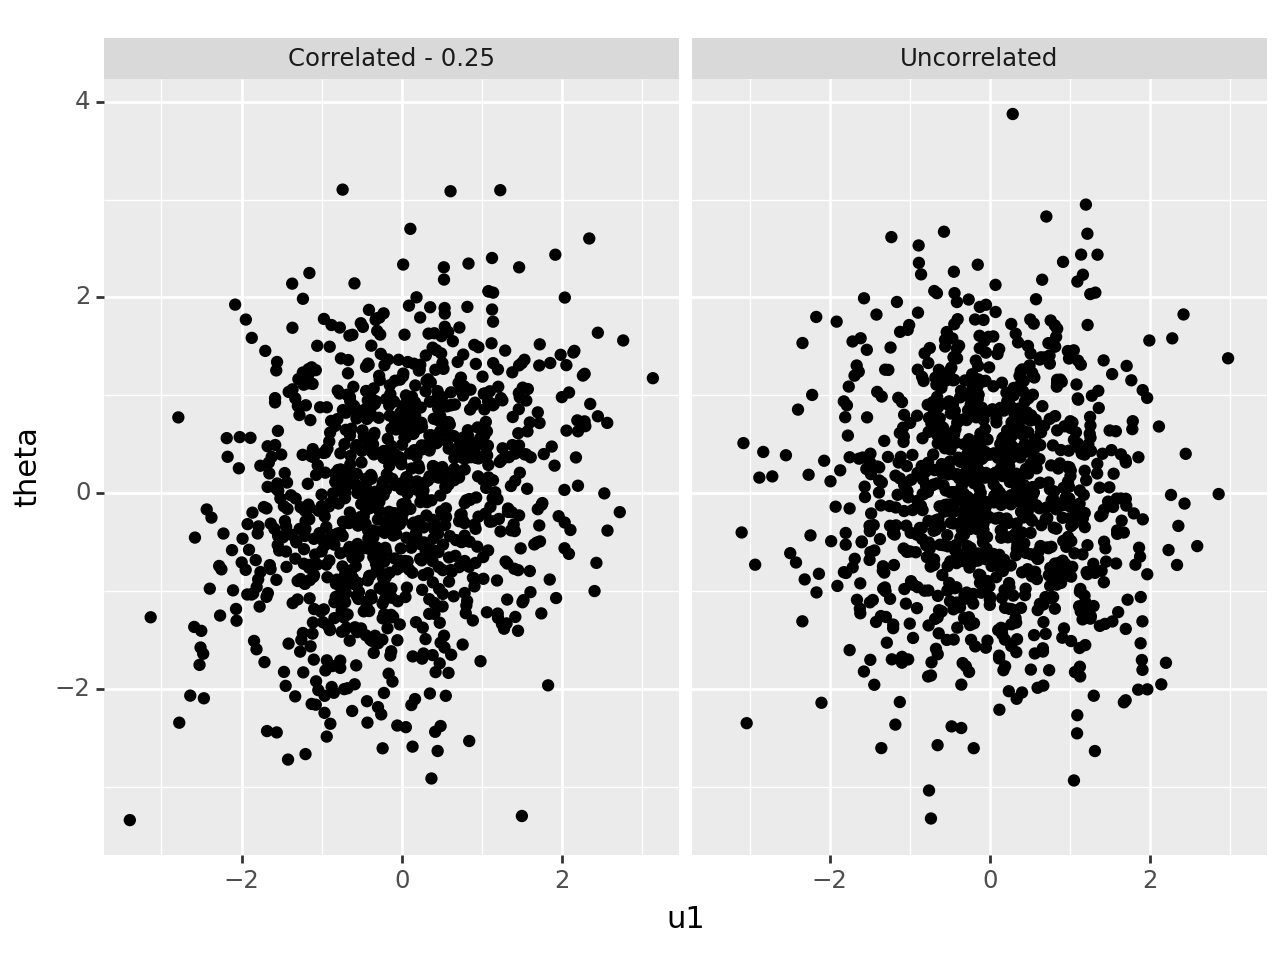

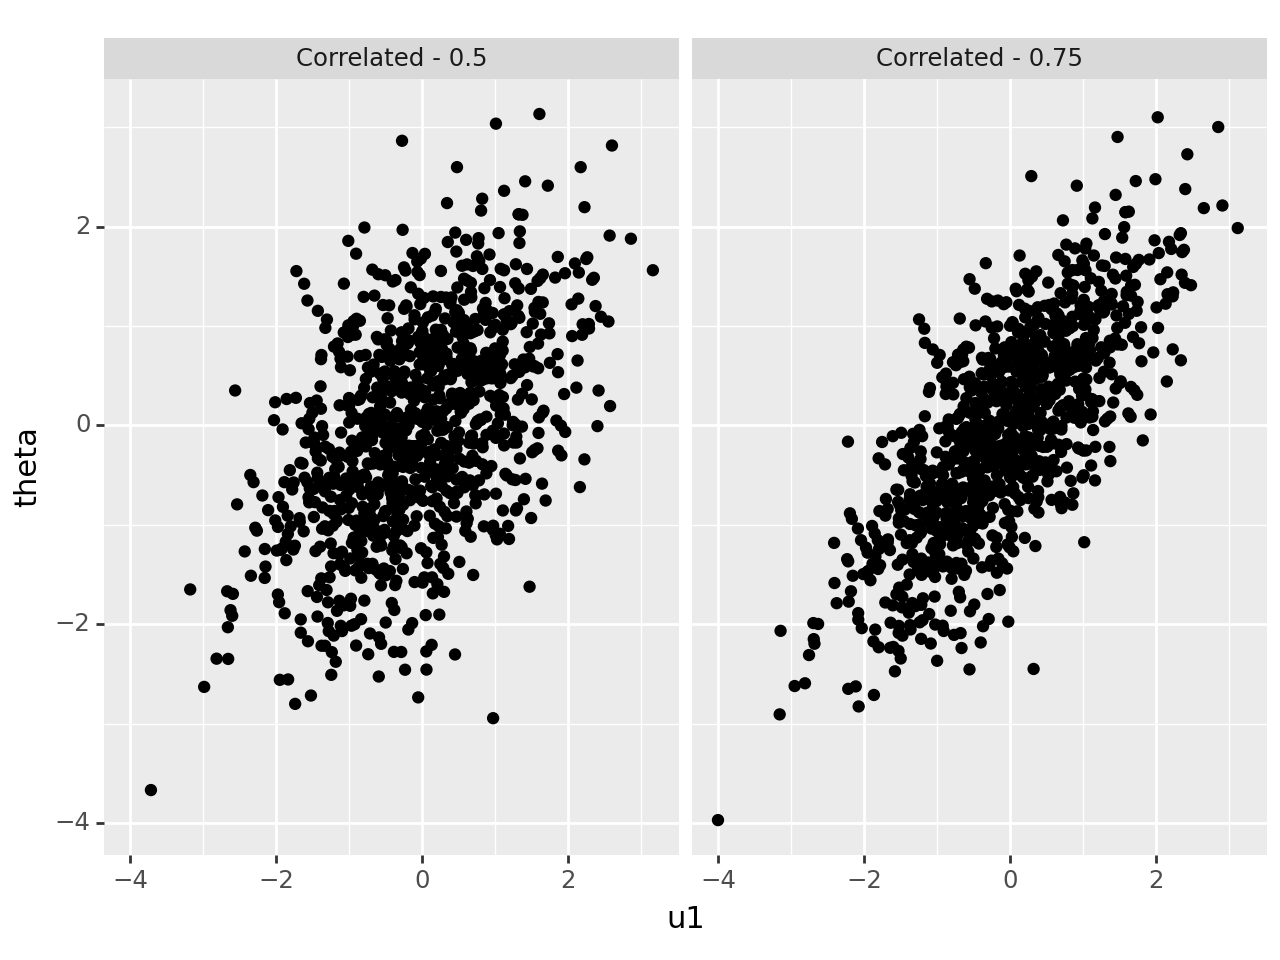

In [17]:
# Control Correlation between u1 and direction
# Uncorrelated gaussian
md_no_corr = (
    gr.Model("Uncorrelated gaussian")
    >> gr.cp_marginals(
        u1=dict(dist="norm", loc=0, scale=1),
        theta=dict(dist="norm", loc=0, scale=1),
    )
    >> gr.cp_copula_independence()
)

# Correlated gaussian
md_corr_0_25 = (
    gr.Model("Uncorrelated gaussian - 0.25")
    >> gr.cp_marginals(
        u1=dict(dist="norm", loc=0, scale=1),
        theta=dict(dist="norm", loc=0, scale=1),
    )
    >> gr.cp_copula_gaussian(df_corr=gr.df_make(corr=0.25, var1="u1", var2="theta"))
)

md_corr_0_5 = (
    gr.Model("Uncorrelated gaussian - 0.5")
    >> gr.cp_marginals(
        u1=dict(dist="norm", loc=0, scale=1),
        theta=dict(dist="norm", loc=0, scale=1),
    )
    >> gr.cp_copula_gaussian(df_corr=gr.df_make(corr=0.5, var1="u1", var2="theta"))
)

md_corr_0_75 = (
    gr.Model("Uncorrelated gaussian - 0.75")
    >> gr.cp_marginals(
        u1=dict(dist="norm", loc=0, scale=1),
        theta=dict(dist="norm", loc=0, scale=1),
    )
    >> gr.cp_copula_gaussian(df_corr=gr.df_make(corr=0.75, var1="u1", var2="theta"))
)

# Draw realizations
df_no_corr = gr.eval_sample(md_no_corr, n=1e3, df_det="nom", skip=True, seed=101)
df_corr_0_25 = gr.eval_sample(md_corr_0_25, n=1e3, df_det="nom", skip=True, seed=101)
df_corr_0_5 = gr.eval_sample(md_corr_0_5, n=1e3, df_det="nom", skip=True, seed=101)
df_corr_0_75 = gr.eval_sample(md_corr_0_75, n=1e3, df_det="nom", skip=True, seed=101)


# Visualize
p1 = (
    df_corr_0_25 >> gr.tf_mutate(source="Correlated - 0.25")
    >> gr.tf_bind_rows(
        df_no_corr >> gr.tf_mutate(source="Uncorrelated"),
    )
    >> gr.ggplot(gr.aes("u1", "theta"))
    + gr.geom_point()
    + gr.facet_wrap("source")
)

# Visualize
p2 = (
    df_corr_0_5 >> gr.tf_mutate(source = "Correlated - 0.5")
    >> gr.tf_bind_rows(
        df_corr_0_75 >> gr.tf_mutate(source = "Correlated - 0.75")
    )
    >> gr.ggplot(gr.aes("u1", "theta"))
    + gr.geom_point()
    + gr.facet_wrap("source")
)

print(p1)
print(p2)